# Attention

In [1]:
import torch
import torch.nn as nn
import math

def ScaledDotProductAttention(q, k, v, mask):
    b, h, l, d = k.size()
    kt = k.transpose(2,3)
    score = q@kt / math.sqrt(d)
    if mask is not None:
        score = score.masked_fill(mask, -10000)
    score = nn.functional.softmax(score)
    out = score@v
    return out

bs = 4
h = 8 
l = 16
d = 64

q = torch.randn(bs, h, l, d)
k = torch.randn(bs, h, l, d)
v = torch.randn(bs, h, l, d)
m = torch.ones(1, 1, l, l, dtype=torch.bool)
# m = torch.tril(l,l).unsqueeze(0).unsqueeze(0)
out = ScaledDotProductAttention(q,k,v,m)
print(out.shape)

/var/folders/nb/5w4m7xtn6vs7ncl5gs5fs9600000gn/T/ipykernel_43989/4161789820.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  score = nn.functional.softmax(score)


torch.Size([4, 8, 16, 64])

# Multihead Attention

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, head):
        super(MultiHeadAttention, self).__init__()
        self.head = head
        self.dim = dim
        self.wq = nn.Linear(dim,dim)
        self.wk = nn.Linear(dim,dim)
        self.wv = nn.Linear(dim,dim)
        self.wo = nn.Linear(dim,dim)
    def forward(self, x, mask):
        b,l,dim = x.size()
        head_dim = self.dim // self.head 
        q, k, v = self.wq(x), self.wk(x), self.wv(x)
        q = q.view(b,l, head, head_dim).transpose(1,2)
        k = k.view(b,l, head, head_dim).transpose(1,2)
        v = v.view(b,l, head, head_dim).transpose(1,2)
        out = ScaledDotProductAttention(q, k, v, mask)
        out = out.transpose(1,2).reshape(b,l, self.dim)
        out = self.wo(out)
        return out

dim = 512
head = 8
bs = 4
seq_len = 6
MHA = MultiHeadAttention(512, 8)
dummy_x = torch.randn(bs, seq_len, dim)
dummy_mask = torch.ones(1, 1, seq_len, seq_len, dtype=torch.bool)
out = MHA(dummy_x, dummy_mask)
out.shape
    

/var/folders/nb/5w4m7xtn6vs7ncl5gs5fs9600000gn/T/ipykernel_43989/4161789820.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  score = nn.functional.softmax(score)


torch.Size([4, 6, 512])

# SoftMax

In [3]:
import torch
def SoftMax(logits):
    logits = logits.exp()
    logits_max, _ = logits.max(dim = -1)
    # Safe-SoftMax 减去最大值，提高数值稳定性
    logits = logits - logits_max.unsqueeze(1) 
    logits_sum = logits.sum(-1, keepdim = True)
    prob = logits / logits_sum
    prob += 1e-8 # 如果是0, 那么取log会得到 nan或inf
    return prob.abs()
logits = torch.randn(8, 10)
prob = SoftMax(logits)
print(prob[0])
print(prob[1])
print(prob[0,:].sum())

tensor([5.6849e-02, 1.2522e-01, 1.1292e-01, 1.3467e-01, 1.0710e-01, 1.1177e-01,
        1.1517e-01, 1.2565e-01, 1.1066e-01, 1.0000e-08])

tensor([1.0705e-01, 1.0871e-01, 1.1027e-01, 1.0073e-01, 1.1577e-01, 1.0000e-08,
        1.1163e-01, 1.1928e-01, 1.1675e-01, 1.0980e-01])

tensor(1.0000)

# Cross-Entropy loss

In [4]:
# dummy data
import torch
bs = 4
label_nums = 10
dummy_label = torch.randint(high = label_nums - 1,size=(1,bs), dtype = torch.long)
dummy_logits = torch.randn(bs, label_nums)
print(dummy_label)
print(dummy_logits)
dummy_label_one_hot = torch.zeros(bs, label_nums) 
for i in range(bs):
    dummy_label_one_hot[i, dummy_label[0,i]] = 1 
print(dummy_label_one_hot)

tensor([[0, 5, 2, 7]])

tensor([[-1.4167, -1.4605,  0.4453, -0.1299,  1.5665, -0.6691,  0.4309, -0.6900,
         -0.8322,  1.4302],
        [-1.9199,  0.8924,  0.6061,  0.3490,  1.6142, -0.5073, -0.5200, -2.5295,
          0.6080,  0.1809],
        [ 1.5143,  1.0489, -0.8006, -1.8162, -0.0410, -1.1193,  0.4479, -0.3901,
          0.6294,  0.6449],
        [-0.8662, -0.4307, -1.0631, -0.0033, -0.5772,  1.0202, -0.4540,  0.7658,
         -1.7129, -0.8884]])

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])

In [5]:
# Cross-Entropy loss
def CrossEntropyLoss(pred, label):
    b, l = label.size()
    prob = SoftMax(pred)
    neg_log_prob = -prob.log()
    loss = neg_log_prob*label
    loss /= (b*l)
    return loss

loss = CrossEntropyLoss(dummy_logits, dummy_label_one_hot)
print(loss.sum())

tensor(0.2362)

# KV-Cache

In [6]:
class MultiHeadAttention_kv_cache(nn.Module):
    def __init__(self, dim, head):
        super(MultiHeadAttention_kv_cache, self).__init__()
        self.head = head
        self.dim = dim
        self.wq = nn.Linear(dim,dim)
        self.wk = nn.Linear(dim,dim)
        self.wv = nn.Linear(dim,dim)
        self.wo = nn.Linear(dim,dim)
        self.k_cache = self.v_cache = None
        self.mask = None
        
    def forward(self, x, mask):
        b,l,dim = x.size()
        head_dim = self.dim // self.head 
        q, k, v = self.wq(x), self.wk(x), self.wv(x)
        # _,lq, _ = q.size()
        q = q.view(b,l, head, head_dim).transpose(1,2)
        k = k.view(b,l, head, head_dim).transpose(1,2)
        v = v.view(b,l, head, head_dim).transpose(1,2)

        if self.k_cache is None:
            self.k_cache = k
            self.v_cache = v
            self.mask = mask # mask是递增的
        else:
            self.k_cache = torch.cat((self.k_cache,k), dim = -2)
            self.v_cache = torch.cat((self.v_cache,v), dim = -2)
            self.mask = torch.cat((self.mask[:,:,-1,:], torch.ones(1,1,1, dtype=torch.bool)), dim = -1).unsqueeze(2)
        
        out = ScaledDotProductAttention(q, self.k_cache, self.v_cache, self.mask)
        out = out.transpose(1,2).reshape(b, l, self.dim) 
        out = self.wo(out) 
        return out
        
class toy_llm(nn.Module):
    def __init__(self, dim, head, voc_size):
        super(toy_llm, self).__init__()
        self.embedding = nn.Embedding(voc_size, dim)
        self.lm_head = nn.Linear(dim, voc_size)
        self.MHA = MultiHeadAttention_kv_cache(dim, head)
    def forward(self, x, mask):
        x = self.embedding(x)
        x = self.MHA(x, mask)
        x = self.lm_head(x)
        return x
    def generate(self, x, max_new_tokens, mask):
        output = []
        x_id = x
        for i in range(max_new_tokens):
            logtis = self.forward(x_id, mask)
            i =torch.argmax(logtis[:,-1,:], dim = -1)
            i = i.unsqueeze(1)
            x_id = i
            x = torch.cat((x, i), dim = -1)
        return x
        

dim = 512
head = 8
bs = 4
seq_len = 6
max_new_tokens = 10
vocab_size = 100

llm = toy_llm(dim, head, vocab_size)
dummy_x = torch.randint(high = vocab_size - 1, size = (bs, seq_len), dtype=torch.long)
mask = torch.ones(1, 1, seq_len, seq_len, dtype=torch.bool)
print(dummy_x)
y = llm.generate(dummy_x, max_new_tokens, mask)
print(y)

tensor([[59, 35, 94, 40, 96, 44],
        [67, 45, 23,  5, 91, 91],
        [30, 15, 20, 85, 59, 58],
        [38, 80, 21, 37, 43,  0]])

/var/folders/nb/5w4m7xtn6vs7ncl5gs5fs9600000gn/T/ipykernel_43989/4161789820.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  score = nn.functional.softmax(score)


tensor([[59, 35, 94, 40, 96, 44, 53, 53, 53, 53, 53, 64, 53, 53, 53, 53],
        [67, 45, 23,  5, 91, 91, 83, 83, 83, 87, 87, 87,  1,  1, 87,  1],
        [30, 15, 20, 85, 59, 58, 37, 71, 71, 71, 71, 58, 58, 58, 21, 21],
        [38, 80, 21, 37, 43,  0, 60, 86, 86, 86,  4, 25, 25, 86, 45,  4]])

# BPE Tokenizer

In [7]:
def get_stats(ids, counts=None):
    counts = {} if counts is None else counts
    for pair in zip(ids, ids[1:]): # iterate consecutive elements
        counts[pair] = counts.get(pair, 0) + 1
    return counts
print('get stats')
example = [1, 2, 3, 1, 2] # token id 序列
counts = get_stats(example)
print(counts) # 相邻token出现频次

get stats

{(1, 2): 2, (2, 3): 1, (3, 1): 1}

[4, 3, 4]

In [ ]:
def merge(ids, pair, idx):
    newids = []
    i = 0
    while i < len(ids):
        if ids[i] == pair[0] and i < len(ids) - 1 and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2 # 相邻两个token id 匹配上Pair, 那么就进行替换
        else:
            newids.append(ids[i])
            i += 1
    return newids
ids=[1, 2, 3, 1, 2]
pair=(1, 2)
newids = merge(ids, pair, 4)
print(newids)

In [17]:
people = [
    {'name': 'Alice', 'age': 30},
    {'name': 'Bob', 'age': 25},
    {'name': 'Charlie', 'age': 35}
]
oldest = max(people, key=lambda person: person['age'])
print(oldest)

{'name': 'Charlie', 'age': 35}

In [19]:
text = '''   
Large Language Models is all you need,
what can i say, manba out. 
Attention is All you need.
Vision Transformers, 
Generative Pretrained Transformers,
Reinforcement leraning from human feedback
chain of thought is basic resoning tool.
LLMs can evaluate NLP results.
Richard Sutton Refinforcement Learning Introduction edition 2.
encoder-only
'''

text_bytes = text.encode("utf-8") # raw bytes
ids = list(text_bytes) # list of integers in range 0..255
print(len(ids))

347

In [27]:
class BasicTokenizer():
    def __init__(self):
        # def __init__(self):
        self.merges = {} # (int, int) -> int
        self.vocab = self.build_vocab() # int -> bytes
        
    def build_vocab(self):
        vocab = {idx: bytes([idx]) for idx in range(256)}
        for (p0, p1), idx in self.merges.items():
            vocab[idx] = vocab[p0] + vocab[p1]
        return vocab

    def train(self, text, vocab_size, verbose=False):
        assert vocab_size >= 256
        num_merges = vocab_size - 256

        text_bytes = text.encode("utf-8") 
        ids = list(text_bytes) 

        merges = {} 
        vocab = {idx: bytes([idx]) for idx in range(256)} # int -> bytes
        for i in range(num_merges):
            stats = get_stats(ids)
            pair = max(stats, key=stats.get)
            idx = 256 + i
            ids = merge(ids, pair, idx)
            merges[pair] = idx
            vocab[idx] = vocab[pair[0]] + vocab[pair[1]]
            # prints
            if verbose:
                print(f"merge {i+1}/{num_merges}: {pair} -> {idx} ({vocab[idx]}) had {stats[pair]} occurrences")
        self.merges = merges # used in encode()
        self.vocab = vocab   # used in decode()

bpe = BasicTokenizer()
bpe.train(text, vocab_size = 300)
for i in range(256,300,1):
    print(bpe.vocab[i])

print(bpe.merges)

b'n '

b'in'

b'an'

b's '

b'ed'

...

b'Tr'

b'Tran'

b'Trans'

b'Transfor'

{
    (110, 32): 256,
    (105, 110): 257,
    (97, 110): 258,
    (115, 32): 259,
    (101, 100): 260,
    (101, 110): 261,
    (111, 256): 262,
    (101, 114): 263,
    (101, 32): 264,
    (111, 117): 265,
    (116, 32): 266,
    (116, 105): 267,
    (46, 10): 268,
    (102, 111): 269,
    (269, 114): 270,
    (32, 10): 271,
    (97, 114): 272,
    (111, 100): 273,
    (105, 259): 274,
    (101, 260): 275,
    (97, 256): 276,
    (98, 97): 277,
    (267, 262): 278,
    (114, 101): 279,
    (257, 103): 280,
    (280, 32): 281,
    (103, 264): 282,
    (117, 97): 283,
    (97, 108): 284,
    (108, 32): 285,
    (285, 121): 286,
    (286, 265): 287,
    (287, 32): 288,
    (288, 110): 289,
    (289, 275): 290,
    (44, 10): 291,
    (104, 97): 292,
    (99, 276): 293,
    (116, 116): 294,
    (115, 105): 295,
    (84, 114): 296,
    (296, 258): 297,
    (297, 115): 298,
    (298, 270): 299
}

In [15]:
# encoder
# utf-8 token ids
text = 'i love transfromers'
text_bytes = text.encode("utf-8") # raw bytes
# 首先对数据转成 字符 的token id
# 再将raw token id 按照 merges表 对raw token id 进行合并 -> token_id

# bpe token ids
ids = list(text_bytes) # list of integers in range 0..255
while len(ids) >= 2:
    stats = get_stats(ids)
    # ids = (2,3,4,5)
    # stats为原文本相邻值统计。   text： pair(2,3),       (3,4),     (3,5)
    # key为筛选merges集合里有效的 词表： pair             (3,4)~268,   (3,5)~289,
    # 此时选出pair(3,4) 268, (3,5) 289
    # 取 bpe.merges.get([3,4]) = 268
    # 取 bpe.merges.get([3,5]) = 289
    # 取 bpe.merges.get([2,3]) = inf
    # 结果取min，是指merge对应idx越小，出现的频率越高
    pair = min(stats, key=lambda p: bpe.merges.get(p, float("inf"))) 
    print(pair)
    print(bpe.vocab[pair[0]], bpe.vocab[pair[1]])
    if pair not in bpe.merges:
        break 
    idx = bpe.merges[pair] # (3,4) -> 268
    ids = merge(ids, pair, idx) # (2,3,4,5) -> (2, 268, 5)
print(ids)

# 解码
text_bytes = b"".join(bpe.vocab[idx] for idx in ids)
decode_text = text_bytes.decode("utf-8", errors="replace")
print(decode_text)

(97, 110)

b'a' b'n'

(101, 114)

b'e' b'r'

(101, 32)

b'e' b' '

(105, 32)

b'i' b' '

[105, 32, 108, 111, 118, 264, 116, 114, 258, 115, 102, 114, 111, 109, 263, 115]

i love transfromers

# Linear Regression

tensor([[1.9634],
        [1.1668]])

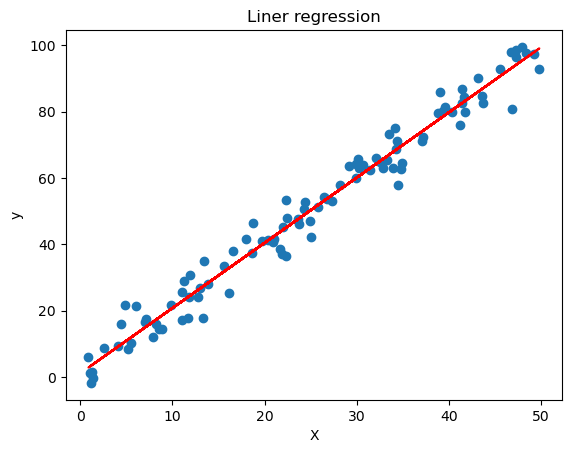

In [14]:
import matplotlib.pyplot as plt
n = 100
x = torch.rand(size = (n, 1), dtype = torch.float32) * 50.0
noisy = torch.randn(size = (n, 1), dtype = torch.float32) * 5.0
y = 2 * x + noisy + 1 # label\
x_input = torch.cat((x, torch.ones(n, 1)), dim = 1 ) # n, 2
w = torch.rand(size=(2,1), dtype = torch.float32)  

def forward(x, w): 
    return x@w    # n, 1

# y^2 + 2y*y_label + y-label^2
# 
lr = 0.001
def train(x, w, y):
    b,d = x.size()
    for i in range(10000):
        y_pred = forward(x, w)
        grad = x.transpose(1,0) @ (y-y_pred) #2,n  n,1 
        w = w + (1.0 / (2.0*b)) * lr * grad
    return w

w_update = train(x_input,w,y)    
print(w_update)

plt.scatter(x, y)
plt.plot(x, forward(x_input, w_update), color='red')
plt.title('Liner regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## adamW

In [ ]:
ref
https://www.ruder.io/optimizing-gradient-descent/
https://medium.com/%E9%9B%9E%E9%9B%9E%E8%88%87%E5%85%94%E5%85%94%E7%9A%84%E5%B7%A5%E7%A8%8B%E4%B8%96%E7%95%8C/%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92ml-note-sgd-momentum-adagrad-adam-optimizer-f20568c968db
https://gaomj.cn/sgd-adam/
Claude-3.5-Sonnet 提供初版代码，

In [46]:
import torch

# model
# y = x @ w

# evaluation
# loss = 0.5 ||x @ w - label||^2


class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.w = w
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        
        self.m = torch.zeros_like(w)
        self.v = torch.zeros_like(w) 
        self.t = 0
    
    def step(self, w,  grad, weight_decay=1e-2):
        self.t += 1

        # 一阶估计，调整
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        # 二阶估计，调整学习率
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad.pow(2)
        
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        if weight_decay is not None: # adamW
            return w - self.lr * (m_hat / (v_hat.sqrt() + self.eps) + weight_decay * w)

        return w - self.lr * m_hat / (v_hat.sqrt() + self.eps)

w = torch.randn(10, 1)
optimizer = Adam(w)
input_data = torch.randn(8,10);
target = torch.randn(8,1);

def loss_function(pred, label):
    b, _ = pred.size()
    return (0.5 / b )*(pred-label) ** 2.0


for epoch in range(1000):
    # 前向传播
    output = input_data @ w
    grad = input_data.transpose(1,0) @ (output - target) 
    if epoch % 100 == 0:
        print(loss_function(output, target).mean())

    # weight_decay = 1e-2 ~ AdamW
    w = optimizer.step(w, grad, weight_decay=None) 
    # w = optimizer.step(w, grad, weight_decay=1e-2) 
    

tensor(0.2119)

tensor(0.1479)

tensor(0.1035)

tensor(0.0727)

tensor(0.0519)

tensor(0.0382)

tensor(0.0293)

tensor(0.0234)

tensor(0.0195)

tensor(0.0167)

# autograd

Ref:

torch autograd introduction:

https://www.youtube.com/watch?v=tIeHLnjs5U8

https://cloud.tencent.com/developer/article/2370294

https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html


Andrej Karpathy:

https://www.youtube.com/watch?v=VMj-3S1tku0&t=1371s

https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_first_half_roughly.ipynb

## 安装环境

In [76]:
!pip install graphviz

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [77]:
from graphviz import Digraph

此段代码仅用于可视化，可视化计算图

In [78]:
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

## 创建节点

In [79]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [80]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

# 前向计算

In [81]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [82]:
# draw_dot(L)

# 梯度更新

In [83]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-8.0

## autograd 实例

### forward

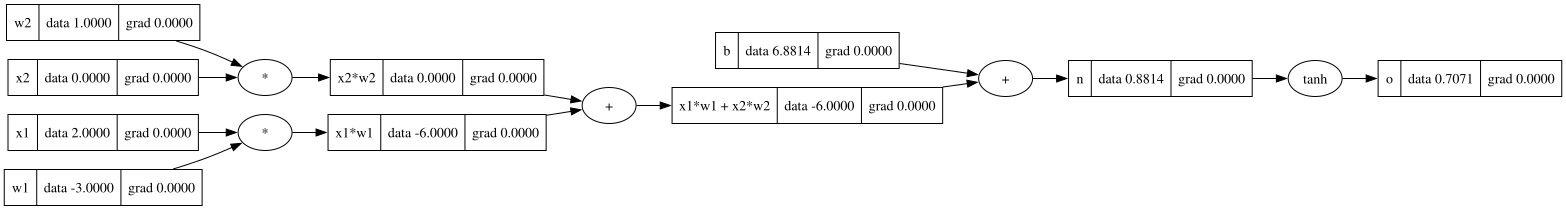

In [87]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

### backward

In [85]:
o.backward()
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]